Sample of the DataFrame:


,Date,Target_1,Target_2,Target_3,Target_4,Target_5,Target_6,Target_7
0,2023-01-01,0.000000,0.000000,0.000000,5.000000,10.000000,5.496714,25.000000
1,2023-01-02,0.134228,0.670637,0.017387,4.988743,9.371069,4.861736,24.333363
2,2023-01-03,0.268456,1.338255,0.049177,4.955025,8.816568,5.647689,23.675735
3,2023-01-04,0.402685,1.999847,0.090345,4.898995,8.324022,6.523030,23.027116
4,2023-01-05,0.536913,2.652434,0.139095,4.820907,7.883598,4.765847,22.387505



Mean Squared Error: 0.2314


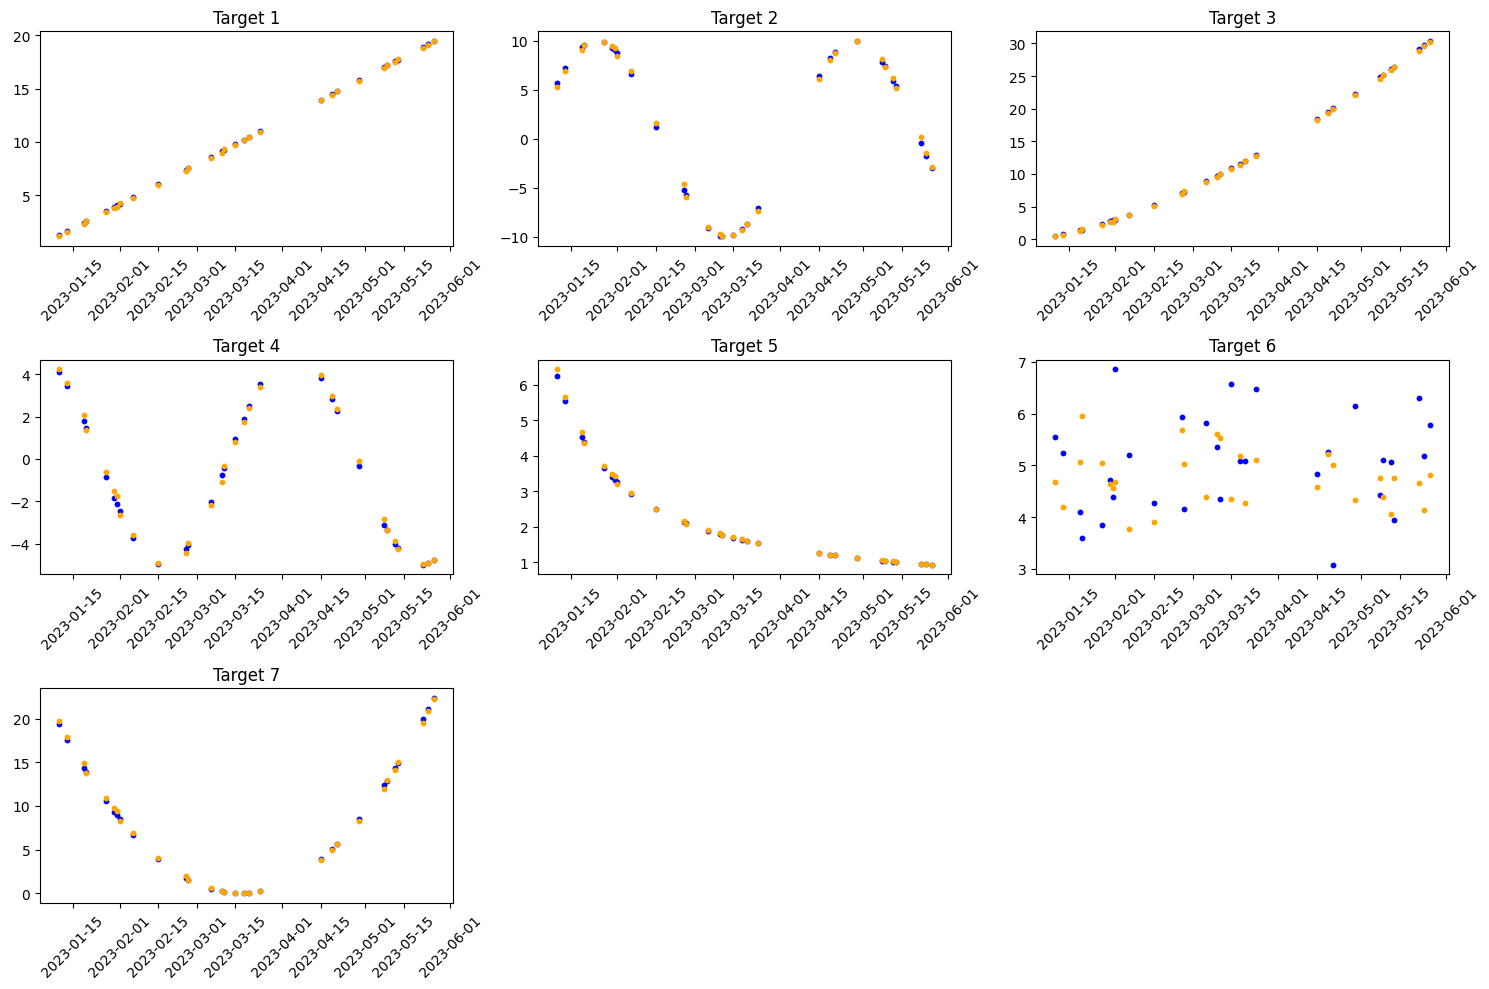

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import datetime as dt

# 1. Generate synthetic data with Dates
np.random.seed(42)
n_samples = 150
dates = pd.date_range(start='2023-01-01', periods=n_samples, freq='D')

# Convert dates to numeric (ordinal) for the model to understand time as a feature
X_numeric = np.array([d.toordinal() for d in dates]).reshape(-1, 1)

# Create 7 targets based on the timeline (X_numeric scaled for variety)
time_steps = np.linspace(0, 10, n_samples)
y = np.stack([
    time_steps * 2,                # Target 1: Linear growth
    np.sin(time_steps) * 10,       # Target 2: Seasonal cycle
    time_steps**1.5,               # Target 3: Accelerating growth
    np.cos(time_steps) * 5,        # Target 4: Inverse cycle
    10 / (time_steps + 1),         # Target 5: Decay
    np.random.normal(5, 1, 150),   # Target 6: Random noise
    (time_steps - 5)**2            # Target 7: U-shape trend
], axis=1)

# 2. Create Pandas DataFrame
df = pd.DataFrame(y, columns=[f'Target_{i+1}' for i in range(7)])
df.insert(0, 'Date', dates)

print("Sample of the DataFrame:")
display(df.head())

# 3. Prepare for Machine Learning
# Feature: Date (ordinal), Targets: y
X = X_numeric
y_targets = df.drop(columns=['Date']).values

X_train, X_test, y_train, y_test = train_test_split(X, y_targets, test_size=0.2, random_state=42)

# 4. Train Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 5. Predict and Evaluate
y_pred = model.predict(X_test)
print(f"\nMean Squared Error: {mean_squared_error(y_test, y_pred):.4f}")

# 6. Plotting results
plt.figure(figsize=(15, 10))
for i in range(7):
    plt.subplot(3, 3, i+1)
    # Convert numeric X back to dates for plotting
    test_dates = [dt.date.fromordinal(int(val)) for val in X_test.flatten()]
    plt.scatter(test_dates, y_test[:, i], color='blue', s=10, label='Actual')
    plt.scatter(test_dates, y_pred[:, i], color='orange', s=10, label='Pred')
    plt.title(f'Target {i+1}')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Inference Process
Now we will provide new 'future' dates to the model and see what it predicts for our 7 targets.

In [8]:
import datetime as dt

# 1. Define new dates for inference (e.g., the next 5 days after our dataset ends)
last_date = df['Date'].max()
new_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=5, freq='D')

# 2. Preprocess input: Convert to ordinal numeric format just like we did for training
X_new = np.array([d.toordinal() for d in new_dates]).reshape(-1, 1)

# 3. Perform Prediction (Inference)
predictions = model.predict(X_new)

# 4. Format results into a readable DataFrame
inference_df = pd.DataFrame(predictions, columns=[f'Predicted_Target_{i+1}' for i in range(7)])
inference_df.insert(0, 'Date', new_dates)

print("Inference Results for New Dates:")
display(inference_df)

Inference Results for New Dates:


,Date,Predicted_Target_1,Predicted_Target_2,Predicted_Target_3,Predicted_Target_4,Predicted_Target_5,Predicted_Target_6,Predicted_Target_7
0,2023-05-31,19.939597,-5.176548,31.480017,-4.268398,0.911619,5.177032,24.702176
1,2023-06-01,19.939597,-5.176548,31.480017,-4.268398,0.911619,5.177032,24.702176
2,2023-06-02,19.939597,-5.176548,31.480017,-4.268398,0.911619,5.177032,24.702176
3,2023-06-03,19.939597,-5.176548,31.480017,-4.268398,0.911619,5.177032,24.702176
4,2023-06-04,19.939597,-5.176548,31.480017,-4.268398,0.911619,5.177032,24.702176
